SUCCESS: Cleaning, Feature Engineering, and Visualizations complete.

Preview of the Cleaned Data:


,Student_ID,Gender,Degree_Program,Type_of_Visual_Impairment,Severity_Level,Braille_Usage,Screen_Reader_Usage,Magnification_Tools,Audio_Books_Usage,Scholarship_Status,...,Stress_Level,Sleep_Hours,Accessibility_Barriers_Score,Classroom_Accessibility,Teacher_Support_Rating,Peer_Support_Level,Academic_Performance,Tech_Adoption_Index,Support_Barrier_Ratio,Academic_Friction
0,VIS001,Female,Economics,Color Blindness,Moderate,Yes,Low,Medium,Occasional,No,...,1.0,4,4.0,10.0,6.0,3.0,2.98,5,2.400000,0.200000
1,VIS002,Female,English Literature,Progressive Vision Loss,Mild,No,High,High,Frequent,No,...,2.0,6,6.0,6.0,8.0,4.0,3.23,9,2.428571,0.285714
2,VIS003,Female,Law,Low Vision,Moderate,Yes,Low,Medium,Occasional,Yes,...,7.0,5,6.0,4.0,4.0,5.0,2.39,5,1.428571,1.166667
3,VIS004,Female,English Literature,Partial Blindness,Moderate,No,Medium,Medium,Occasional,Yes,...,7.0,5,4.0,7.0,7.0,7.0,2.50,5,3.200000,1.166667
4,VIS005,Female,Business Administration,Color Blindness,Moderate,No,High,Medium,Frequent,No,...,1.0,8,3.0,4.0,9.0,5.0,3.46,8,4.500000,0.111111


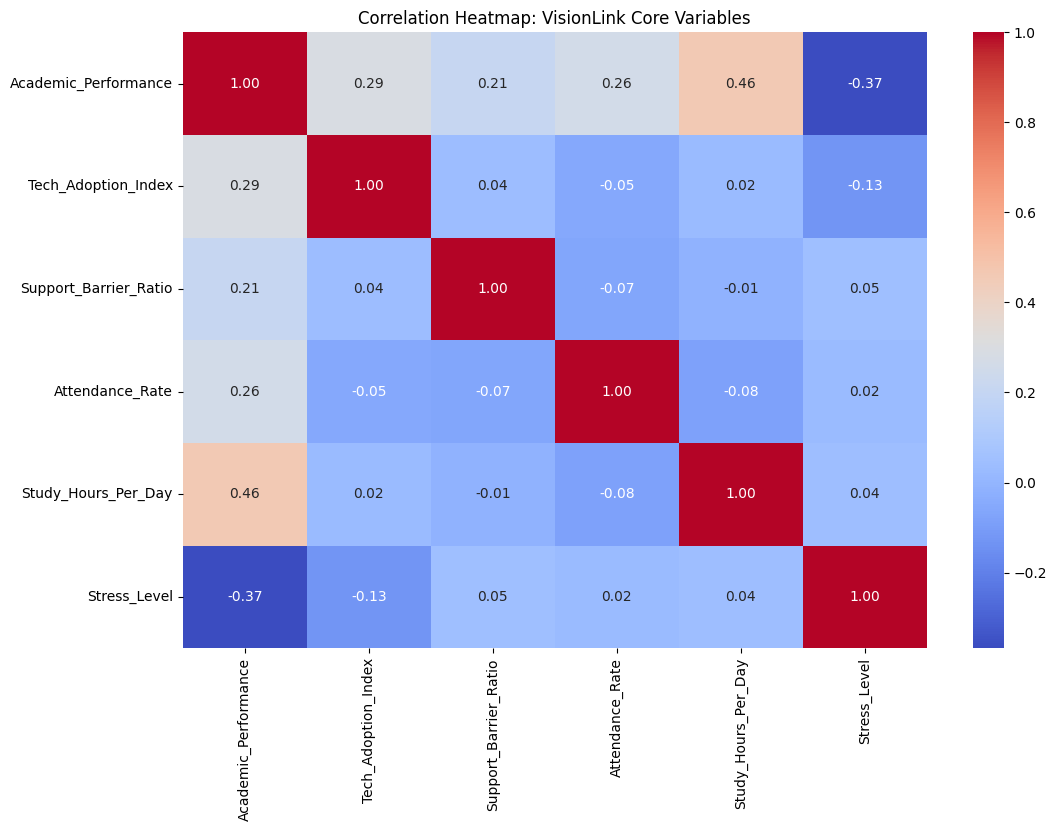

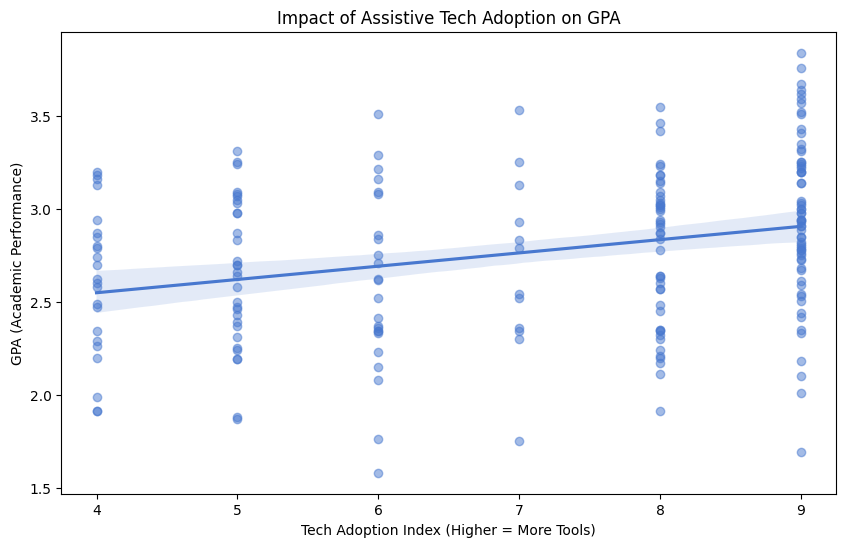

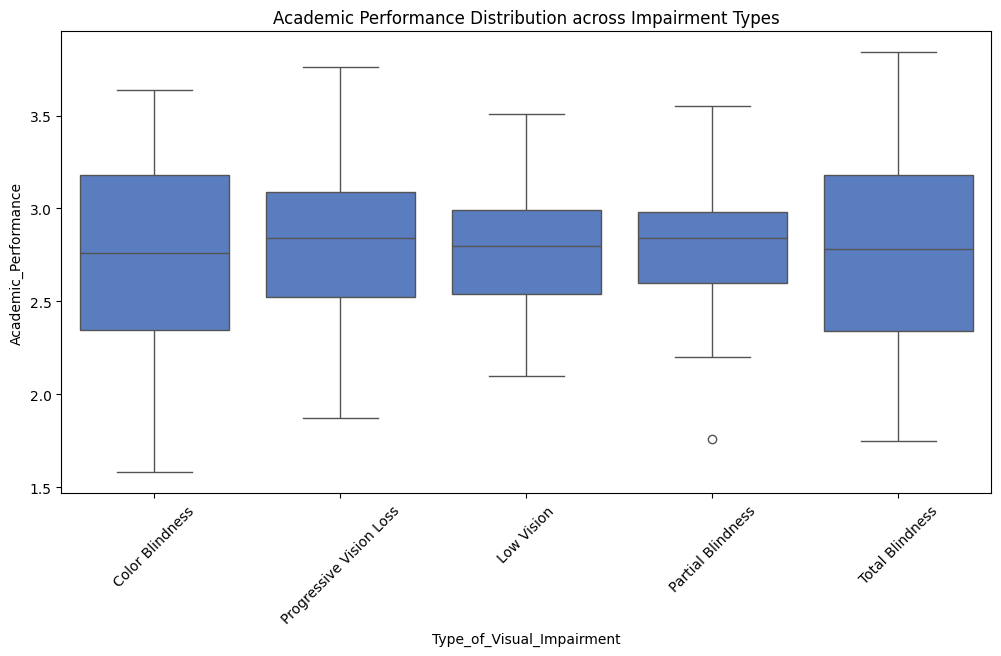

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

# 1. LOAD DATA
# Ensure your file name matches exactly
df = pd.read_csv('visual_impairment_synthetic_datasett.csv')

# 2. ADVANCED DATA CLEANING
def advanced_cleaning(data):
    # Separate numeric and categorical columns
    numeric_df = data.select_dtypes(include=[np.number])
    categorical_df = data.select_dtypes(exclude=[np.number])
    
    # KNN Imputation for Numeric (Fills missing values based on similar students)
    imputer = KNNImputer(n_neighbors=5)
    numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)
    
    # Mode Imputation for Categorical
    for col in categorical_df.columns:
        categorical_df[col] = categorical_df[col].fillna(categorical_df[col].mode()[0])
        
    # Recombine
    return pd.concat([categorical_df, numeric_imputed], axis=1)

df_clean = advanced_cleaning(df)

# 3. FEATURE ENGINEERING (The Senior Data Scientist Layer)

# Transform Sleep_Hours to whole numbers (round and convert to int)
df_clean['Sleep_Hours'] = df_clean['Sleep_Hours'].round().astype(int)

# Mapping categorical usage to ordinal scores for TAI
usage_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Occasional': 1, 'Frequent': 3, 'No': 0, 'Yes': 1}

# Calculate Tech Adoption Index (TAI)
df_clean['Tech_Adoption_Index'] = (
    df_clean['Screen_Reader_Usage'].map(usage_map).fillna(0) +
    df_clean['Magnification_Tools'].map(usage_map).fillna(0) +
    df_clean['Audio_Books_Usage'].map(usage_map).fillna(0) +
    df_clean['Braille_Usage'].map(usage_map).fillna(0)
)

# Support-to-Barrier Ratio: (Institutional + Teacher Support) / (Barriers)
# We add +1 to avoid division by zero
df_clean['Support_Barrier_Ratio'] = (
    df_clean['Institutional_Support_Rating'] + df_clean['Teacher_Support_Rating']
) / (df_clean['Accessibility_Barriers_Score'] + 1)

# Academic Friction Score: Stress vs Sleep/Rest
df_clean['Academic_Friction'] = df_clean['Stress_Level'] / (df_clean['Sleep_Hours'] + 1)

# 4. EXPLORATORY DATA ANALYSIS (VISUALS)
plt.style.use('seaborn-v0_8-muted')

# Visual A: Correlation Heatmap (Crucial for Identifying Model Inputs)
plt.figure(figsize=(12, 8))
corr_matrix = df_clean[['Academic_Performance', 'Tech_Adoption_Index', 'Support_Barrier_Ratio', 
                        'Attendance_Rate', 'Study_Hours_Per_Day', 'Stress_Level']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: VisionLink Core Variables')
plt.savefig('visionlink_correlation_heatmap.png')

# Visual B: Tech Adoption vs. Performance (The Problem Statement Evidence)
plt.figure(figsize=(10, 6))
sns.regplot(x='Tech_Adoption_Index', y='Academic_Performance', data=df_clean, scatter_kws={'alpha':0.5})
plt.title('Impact of Assistive Tech Adoption on GPA')
plt.xlabel('Tech Adoption Index (Higher = More Tools)')
plt.ylabel('GPA (Academic Performance)')
plt.savefig('tech_vs_gpa.png')

# Visual C: Performance by Impairment Type (The Context Layer)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Type_of_Visual_Impairment', y='Academic_Performance', data=df_clean)
plt.xticks(rotation=45)
plt.title('Academic Performance Distribution across Impairment Types')
plt.savefig('impairment_vs_gpa.png')

# 5. SAVE PREPROCESSED DATA
df_clean.to_csv('visionlink_preprocessed_ready.csv', index=False)
print("SUCCESS: Cleaning, Feature Engineering, and Visualizations complete.")

# 6. SHOW CLEANED DATA
print("\nPreview of the Cleaned Data:")
display(df_clean.head())  # Using display() renders a nice HTML table in Jupyter